# Quantification of Mitochondria in 2D Fluorescent Stacks
- *Isobel Taylor-Hearn, 2023*
- Requires a fluorescent image stack containing (at least) a nuclear channel and mitochondria channel

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math
import os
import pathlib

import skimage
from skimage.feature import peak_local_max
from skimage import util,  restoration
from skimage.filters import threshold_otsu, threshold_isodata
from skimage.segmentation import clear_border, expand_labels, watershed
from skimage.measure import label, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, closing,  disk, dilation
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from tifffile import imread

import warnings
warnings.filterwarnings("ignore")
import pathlib

import contextlib
import joblib
from tqdm import tqdm
from joblib import Parallel, delayed

In [2]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """
    Enables parallel jobs to run and display of a tqdm progress bar.

    Parameters:
    -----------
    tqdm_object : tqdm
        The tqdm progress bar instance to be updated.

    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [3]:
def convert(img, target_type_min, target_type_max, target_type):
    """
    Converts an image to a specified data type while scaling its intensity values.

    This function rescales the intensity values of an image from its original range 
    to a new target range specified by `target_type_min` and `target_type_max`, and 
    then converts it to the desired data type.

    This step is required as deconvolved images are not always scaled 0->255! 

    Parameters:
    -----------
    img : numpy.ndarray
        The input image array to be converted.
    target_type_min : int or float
        The minimum value of the target intensity range.
    target_type_max : int or float
        The maximum value of the target intensity range.
    target_type : numpy.dtype
        The desired data type of the output image (e.g., np.uint8, np.float32).

    Returns:
    --------
    new_img : numpy.ndarray
        The rescaled image with values mapped to the new intensity range and converted 
        to the specified data type.

    Notes:
    ------
    - This function performs a linear transformation to scale pixel values.
    - It ensures that the output values are properly mapped between `target_type_min` and 
      `target_type_max`.
    """
    imin = img.min()
    imax = img.max()

    a = (target_type_max - target_type_min) / (imax - imin)
    b = target_type_max - a * imax
    new_img = (a * img + b).astype(target_type)
    return new_img

In [4]:
def add_image_details(df, filename):
    """
    Adds experimental details extracted from the filename to a dataframe.

    This function parses the filename to infer experimental details such as 
    well number, imaging day, mechanical stiffness condition, and treatment type.
    The extracted details are appended as new columns to the dataframe.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to which image metadata will be added.
    filename : str
        The filename of the image, used to extract experimental details.

    Returns:
    --------
    df : pandas.DataFrame
        The updated dataframe with the following added columns:
        - 'filename': The original filename.
        - 'flag': Segmentation flag indicating potential issues.
        - 'condition': WT, Nic, Tom or Nictom (or unknown if no match found)
    """

    df["image"] = filename
    if "10a" in str(filename).lower():
        df["cell_type"] = "MCF10A"
    else:
        df["cell_type"] = "OTHER"
    if "4oht" in str(filename).lower():
        df["treatment"] = "4OHT" 
    elif "abt" in str(filename).lower():
        df["treatment"] = "ABT737"  
    else:
        df["treatment"] = "OTHER"  
    return df

In [5]:
def segment_nuclei(dapi, pixel_size):
    """
    Segment nuclei and use a watershed segmentation to separate touching objects.
    Filter out any objects below a defined area cutoff.
    Acquired images did not have a membrane marker. Therefore, the code assumes that the border between two cells lies halfway between
        the shortest distance between their nuclei.
    Cell bodies are therefore approximated by expanding nuclear labels without overlap until they fill the image. Cells that touch the border
        or contain nuclei larger than a 15 µm radius equivalent are removed from the analysis.

    Parameters
    ----------
    dapi : ndarray
        Grayscale image of nuclei stained with DAPI.
    pixel_size : float
        Pixel size in microns (µm), used to filter out overly large nuclei.

    Returns
    -------
    dapi_labels : ndarray (int)
        Labeled image of segmented nuclei, where each nucleus has a unique label.
    valid_cell_labels : ndarray (int)
        Labeled image of cell regions corresponding to valid cells. Cells are valid if they don't touch the image border and
            have nuclei smaller than a 15 µm radius equivalent.
    """
    ################## Segment all nuclei #######################################################################################################
    thresh = threshold_otsu(dapi)
    dapi_processed = dapi > thresh
    dapi_processed = closing(dapi_processed, disk(5))
    dapi_processed = remove_small_holes(dapi_processed, area_threshold = 10000)
    dapi_processed = remove_small_objects(dapi_processed, min_size=1000)
    dapi_labels = label(dapi_processed)
    distances = ndi.distance_transform_edt(dapi_processed)
    coordinates = peak_local_max(distances, min_distance = 60) # min_distance = min separation of nuclear COMs
    marker_locations = coordinates.data
    markers = np.zeros(dapi_processed.shape, dtype=np.uint32)
    marker_indices = tuple(np.round(marker_locations).astype(int).T)
    markers[marker_indices] = np.arange(len(marker_locations)) + 1
    markers_big = dilation(markers, disk(5))
    dapi_labels_ws = watershed(-distances, markers_big, mask=dapi_processed)
    dapi_labels = label(dapi_labels_ws + dapi_labels)
    ################## Approximate cell boundaries and exclude cells that touch the border from analysis #########################################
    all_cells_labels = clear_border(expand_labels(dapi_labels, 1000)) # any cells that don't touch the border
    nuclear_props = regionprops_table(dapi_labels, dapi, properties=("label", "area"))  
    condition = (nuclear_props['area'] <= np.pi *((15*pixel_size)**2)) # filter out any cells with nuclei more than 15um radius equivalent
    input_labels = nuclear_props['label']
    output_labels = input_labels * condition
    valid_cell_labels = util.map_array(all_cells_labels, input_labels, output_labels) # only keep the cells with nuclei that pass the area test
    return dapi_labels, valid_cell_labels

In [6]:
def segment_mitochondria(mito, background_subtraction):
    """
    Segment mitochondria from a grayscale fluorescence image.

    Parameters
    ----------
    mito : ndarray
        Grayscale image of mitochondria, where mitochondria appear bright on a dark background.
    background_subtraction : bool
        If True, applies rolling ball background subtraction before segmentation.

    Returns
    -------
    binary_mito : ndarray (bool)
        Binary mask of segmented mitochondria.
    mito_labels : ndarray (int)
        Labeled image of mitochondria, where each connected component has a unique integer label.
    """
    if background_subtraction == True:
        print("Background Subtraction Applied")
        background = restoration.rolling_ball(mito, radius = 11)
        mito_processed = mito - background
    else:
        mito_processed = mito
    thresh=threshold_isodata(mito_processed)
    binary_mito = mito_processed > thresh
    mito_labels = label(binary_mito)
    return binary_mito, mito_labels

In [7]:
def segment_nuclei_and_mitochondria(image_paths, i, to_plot = True, dapi_channel = 0, mito_channel = 1, pixel_size = 7.4627, background_subtraction=False):
    """
    Segment nuclei and mitochondria from a multi-channel image and quantify mitochondrial content per cell.

    This function processes a specified image from a list of file paths, segments nuclei and cells using
    the DAPI channel, and segments mitochondria using a mitochondrial fluorescence channel. It optionally 
    visualizes the segmentation and performs quantification of mitochondrial area per cell, as well as the 
    distribution of mitochondria as a function of distance from the nucleus.

    Parameters
    ----------
    image_paths : list of str
        List of file paths to multi-channel microscopy images.
    i : int
        Index of the image in `image_paths` to process.
    to_plot : bool, optional (default=True)
        Whether to generate and save a plot showing segmentation steps.
    dapi_channel : int, optional (default=0)
        Channel index for DAPI (nuclear stain).
    mito_channel : int, optional (default=1)
        Channel index for mitochondrial fluorescence.
    pixel_size : float, optional (default=7.4627, this is correct for the Zeiss Axio Imager 63x lens)
        Pixel size in microns, used to convert area and distance to physical units.
    background_subtraction : bool, optional (default=False)
        Whether to apply rolling ball background subtraction to the mitochondrial image before segmentation.

    Returns
    -------
    mito_area_df : pandas.DataFrame
        Per-cell summary table containing:
        - 'image': image name
        - 'cell_type': cell line extracted from the filename (update choices in "add_image_details")
        - 'treatment': treatment extracted from the filename (update choices in "add_image_details")
        - 'cell_label': integer cell identifier
        - 'cell_area_um': cell area (µm²)
        - 'mito_area_um': mitochondrial area (µm²)
        - 'mito/cell_area': mitochondrial fraction (mitochondrial area / cell area)

    mito_distance_df : pandas.DataFrame
        Pixel-level table showing mitochondrial presence as a function of distance from the nucleus for each cell.
        Includes:
        - 'image': image name
        - 'cell_type': cell line extracted from the filename (update choices in "add_image_details")
        - 'treatment': treatment extracted from the filename (update choices in "add_image_details")
        - 'cell_label': integer cell identifier
        - "rounded_distance": rounded distance from the edge of the nucleus (µm)
        - "count": binary indicator of mitochondrial presence in each pixel
        Returns an empty DataFrame if no valid cells are found.
    """
    filename = os.path.basename(image_paths[i]).split(".")[0]
    image = imread(image_paths[i])
    dapi = convert(image[dapi_channel,:,:], 0, 255, np.uint8)
    mito = convert(image[mito_channel,:,:], 0, 255, np.uint8)

    rgb_image = np.stack([np.zeros_like(dapi), mito, dapi], axis=-1)

    dapi_labels, cell_labels = segment_nuclei(dapi, pixel_size=pixel_size)
    binary_mito, mito_labels = segment_mitochondria(mito, background_subtraction)
    
    if to_plot == True:
        fig, ax = plt.subplots(ncols = 4, figsize=(20,5))
        ax[0].imshow(rgb_image)
        ax[1].imshow(dapi, alpha = 0.7, cmap="gray", interpolation = "none")
        ax[1].imshow(np.ma.masked_where(dapi_labels == 0, dapi_labels), cmap="jet", alpha=0.5, interpolation="none")
        ax[1].imshow(np.ma.masked_where(cell_labels == 0, cell_labels), cmap="jet", alpha=0.5, interpolation="none")
        ax[2].imshow(mito, alpha = 0.7, cmap="gray", interpolation = "none")
        ax[2].imshow(np.ma.masked_where(mito_labels == 0, mito_labels), cmap="jet", alpha=0.5, interpolation="none")
        ax[3].imshow(rgb_image)
        ax[3].imshow(np.ma.masked_where((dapi_labels == 0) | (cell_labels == 0), dapi_labels), alpha=1, cmap="gray", interpolation="none")
        ax[3].imshow(np.ma.masked_where((mito_labels == 0) | (cell_labels == 0), mito_labels), alpha=0.8, cmap="jet", interpolation="none")
        for a in ax:
            a.axis("off")
################## Basic Quantification #######################################################################################################
    mito_area_df = pd.DataFrame(regionprops_table(cell_labels, dapi, properties=("label", "area")) )
    mito_area_df["mito/cell_area"]= mito_area_df.apply(lambda row: binary_mito[cell_labels == row["label"]].sum() / row["area"], axis=1)
    mito_area_df["mito_area_um"] = mito_area_df.apply(lambda row: (binary_mito[cell_labels == row["label"]].sum())* ((1/pixel_size)**2), axis=1)
    mito_area_df["cell_area_um"] = mito_area_df["area"] * ((1/pixel_size)**2)
    mito_area_df = add_image_details(mito_area_df, filename)
    mito_area_df = mito_area_df.rename(columns={'label': 'cell_label'})
    mito_area_df = mito_area_df[['image', 'cell_type', 'treatment', 'cell_label', 'cell_area_um', 'mito_area_um', 'mito/cell_area']]

################## Mitochondria Distance from Nucleus Analysis ##################################################################################
    try: # if full cells are identified
        mito_distance_df = []
        for i in np.unique(cell_labels):
            if i != 0:       
                nuc_of_interest = dapi_labels * (dapi_labels == i) > 0 
                cell_of_interest = cell_labels * (cell_labels == i) > 0 
                distance = ((distance_transform_edt(1- (nuc_of_interest))) * cell_of_interest) * (1/pixel_size)
                binary_mito_in_cell = cell_of_interest * binary_mito
                count_with_distance = pd.DataFrame(zip(np.ravel(distance), np.ravel(binary_mito_in_cell)), columns=['distance', 'count'])   
                count_with_distance["cell_label"] = i
                mito_distance_df.append(count_with_distance) # looks at every pixel at every distance and evaluates is this pixel filled by mitochondria
        mito_distance_df = pd.concat(mito_distance_df).reset_index()
        mito_distance_df = mito_distance_df[mito_distance_df.distance != 0]
        mito_distance_df['rounded_distance'] = mito_distance_df['distance'].apply(lambda x: round(x, 2))
        mito_distance_df = add_image_details(mito_distance_df, filename)

        mito_distance_df = mito_distance_df[['image', 'cell_type', 'treatment', 'cell_label', 'rounded_distance', 'count']]
    except:
        mito_distance_df = pd.DataFrame()
    return (mito_area_df, mito_distance_df)

In [8]:
def plot_outputs(df, max_distance_quantile=50):
    """
    Plot mitochondrial distribution as a function of distance from the nucleus for each cell.

    This function aggregates and smooths pixel-level mitochondrial occupancy data per cell. It filters
    distances to include only those observed in at least a specified percentage of cells, then applies a 
    rolling average to smooth the data and generates two plots:
    1. Proportion of pixels at a given distance that contain mitochondria
    2. Absolute number of mitochondrial pixels at each distance

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame containing columns:
        - 'cell_label': int, unique ID per cell
        - 'rounded_distance': float, distance from nucleus in microns
        - 'count': int, binary indicator of whether pixel is occupied by mitochondria (0 or 1)

    max_distance_quantile : float, optional (default=50)
        Distance cutoff threshold. Only distances observed in at least this percentage of cells are included
        in the analysis.

    Returns
    -------
    smoothed : pandas.DataFrame
        Smoothed and filtered DataFrame with per-cell mitochondrial occupancy statistics.
    """
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    df["count"] = df["count"].astype(int)
    df = (df.groupby(["cell_label", "rounded_distance"])["count"].agg(["sum", "count"]).rename(columns={
            "sum": "number_of_mito_at_distance",
            "count": "number_of_pixels_at_distance"
        }).reset_index())
    df["proportion_of_pixels_with_mito"] = (df["number_of_mito_at_distance"] / df["number_of_pixels_at_distance"])

    # Keep only distances present in >= max_distance_quantile% of cells
    distance_counts = df.groupby("rounded_distance")["cell_label"].nunique()
    threshold = (max_distance_quantile / 100) * df["cell_label"].nunique()
    valid_distances = distance_counts[distance_counts >= threshold].index
    df = df[df["rounded_distance"].isin(valid_distances)].copy()
    smoothed = (
        df.sort_values(["cell_label", "rounded_distance"])
        .groupby("cell_label")
        .rolling(window=55, center=True, min_periods=1, on="rounded_distance")
        .mean(numeric_only=True)
        .reset_index()
    )
    smoothed["cell_label"] = smoothed["cell_label"].astype(int)

    fig, ax = plt.subplots(ncols=2, figsize=(15,6))
    sns.lineplot(data=smoothed, x="rounded_distance", y="proportion_of_pixels_with_mito", hue="cell_label", palette="gist_rainbow", ax=ax[0])
    sns.lineplot(data=smoothed, x="rounded_distance", y="number_of_mito_at_distance", hue="cell_label", palette="gist_rainbow", ax=ax[1])
    for a in ax:
        a.set_xlabel("Distance from Nucleus (µm)")
    ax[0].set_ylabel("Proportion of Pixels Occupied by Mitochondria")
    ax[1].set_ylabel("Number of Mitochondrial Pixels")

    return smoothed

Background Subtraction Applied


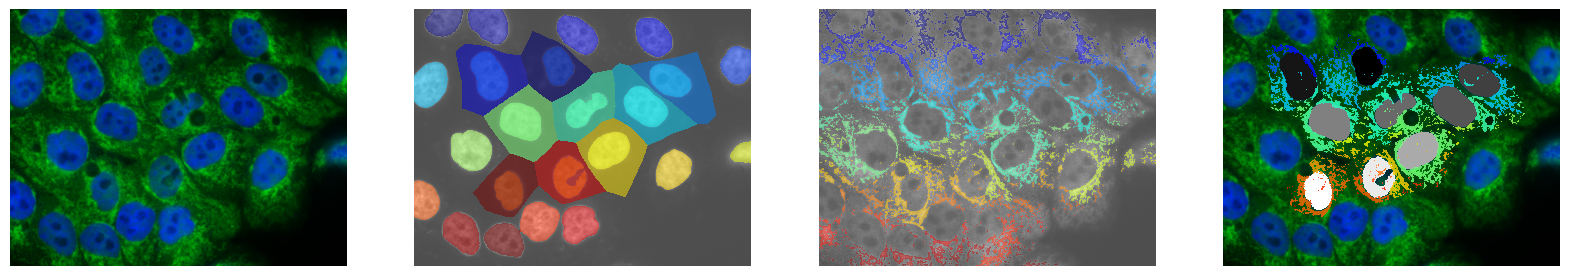

In [9]:
root= "."
image_paths = list(pathlib.Path(root).glob("**/*.tif"))
(mito_area_df, mito_distance_df) = segment_nuclei_and_mitochondria(image_paths, 0, background_subtraction=True)


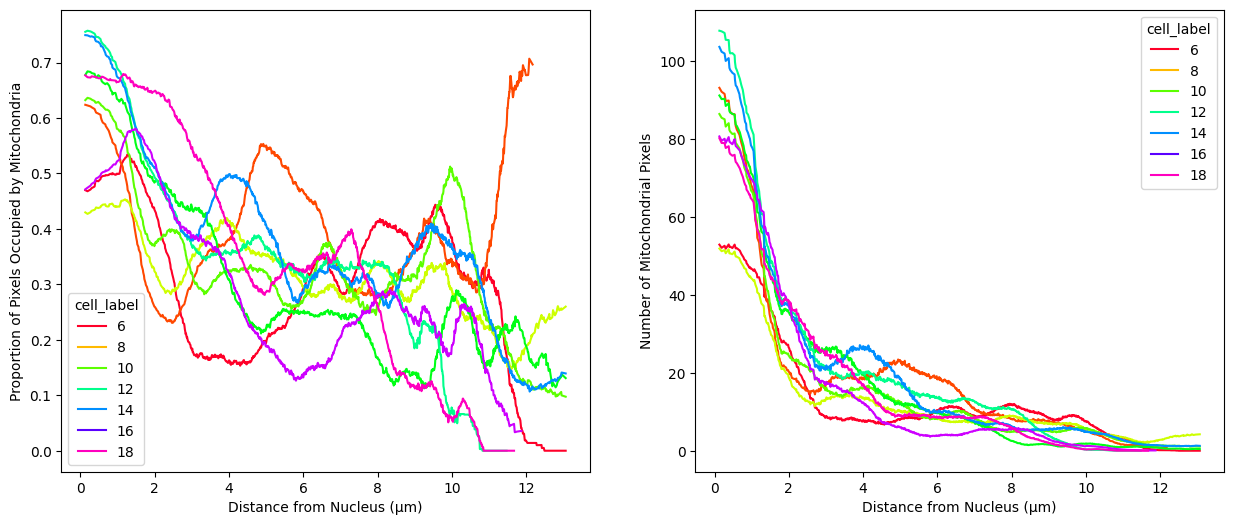

In [10]:
smoothed = plot_outputs(mito_distance_df)

# Analysis for Ungrouped Files

In [ ]:
with tqdm_joblib(tqdm(desc="Image Analysis", total=len(image_paths))) as progress_bar:
    output = Parallel(n_jobs=-1)(delayed(segment_mitochondria)(image_paths, i, to_plot=True) for i in range(len(image_paths)))
total_area = pd.concat([out[0] for out in output])
total_area.to_csv("mito_area_data.csv")
total_dist = pd.concat([out[1] for out in output])
total_dist.to_csv("mito_distance_data.csv")

Image Analysis:   5%|▌         | 10/193 [00:09<02:50,  1.08it/s]
